# Self-training ablations

Compare supervised GD, ordinary self-training, and a clearly labelled oracle-selected-label counterfactual.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy.special import logit

torch.set_default_dtype(torch.float64)
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.experiment_helpers import (
    as_numpy,
    finite_state_observables,
    finite_update_observables,
    make_algorithm_config,
    class_conditional_update_observables,
    trajectory_diagnostics,
    make_parameter_base_sampler,
    mean_and_std,
    run_experiment,
    run_oracle_selected_label_counterfactual,
    state_evolution_state_observables,
    state_evolution_update_observables,
)
from src.asymptotics import MacroscopicStateEvolution
from src.config import DataConfig
from src.environment import FourCellSampleTypeLaw, state_evolution_sample_base_sampler


The oracle curve is a theorem-external finite counterfactual: selected unlabeled observations use their true labels at every update while retaining the same design, initialization, confidence mask, and optimization parameters.  It separates the possible benefit of selected additional samples from the cost of pseudo-label errors.  It is not a realizable algorithm and has no state-evolution claim in this notebook.

In [3]:
SEED = 8100
T, D, DELTA = 150, 2_500, 5.0
K_W, K_G = 6_000, 7_000
common = dict(d=D, delta=DELTA, n_test=4_000, label_prior=0.2, rho=0.05, sigma=1.0, signal_std=1.0, seed=SEED, K_w=K_W, K_g=K_G)

cfg_supervised = make_algorithm_config(T=T, eta=0.5, penalty=0.1, pi=0.0, kappa=logit(0.8))
cfg_self = make_algorithm_config(T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.8))
supervised = run_experiment(name="supervised", algo_cfg=cfg_supervised, **common)
self_training = run_experiment(name="self-training", algo_cfg=cfg_self, **common)
oracle_learner, oracle_callback = run_oracle_selected_label_counterfactual(self_training)

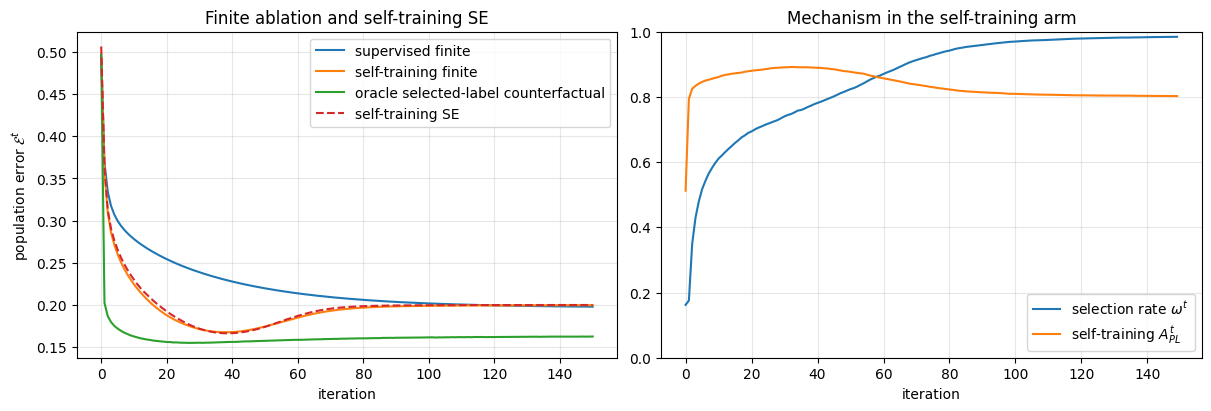

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(supervised.callback.history_["population_error"], label="supervised finite")
axes[0].plot(self_training.callback.history_["population_error"], label="self-training finite")
axes[0].plot(oracle_callback.history_["population_error"], label="oracle selected-label counterfactual")
axes[0].plot(state_evolution_state_observables(self_training)["error"], linestyle="--", label="self-training SE")
axes[0].set(title="Finite ablation and self-training SE", xlabel="iteration", ylabel=r"population error $\mathcal{E}^t$")

self_update = finite_update_observables(self_training)
axes[1].plot(self_update["omega"], label=r"selection rate $\omega^t$")
axes[1].plot(self_update["accuracy"], label=r"self-training $A_{PL}^t$")
axes[1].set(title="Mechanism in the self-training arm", xlabel="iteration", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.show()

The price of pseudo-label noise is summarized by the gap between the ordinary self-training and oracle curves.  Compare that gap with selected-label accuracy and coverage before attributing an effect to the memory mechanism.

In [5]:
SEED = 8100
T, D, DELTA = 350, 2_500, 1.0
K_W, K_G = 6_000, 7_000
common = dict(d=D, delta=DELTA, n_test=4_000, label_prior=0.2, rho=0.01, sigma=1.0, signal_std=1.0, seed=SEED, K_w=K_W, K_g=K_G)

cfg_supervised = make_algorithm_config(T=T, eta=0.5, penalty=0.1, pi=0.0, kappa=logit(0.8))
cfg_self = make_algorithm_config(T=T, eta=0.5, penalty=0.1, pi=2.0, kappa=logit(0.8))
supervised = run_experiment(name="supervised", algo_cfg=cfg_supervised, **common)
self_training = run_experiment(name="self-training", algo_cfg=cfg_self, **common)
oracle_learner, oracle_callback = run_oracle_selected_label_counterfactual(self_training)

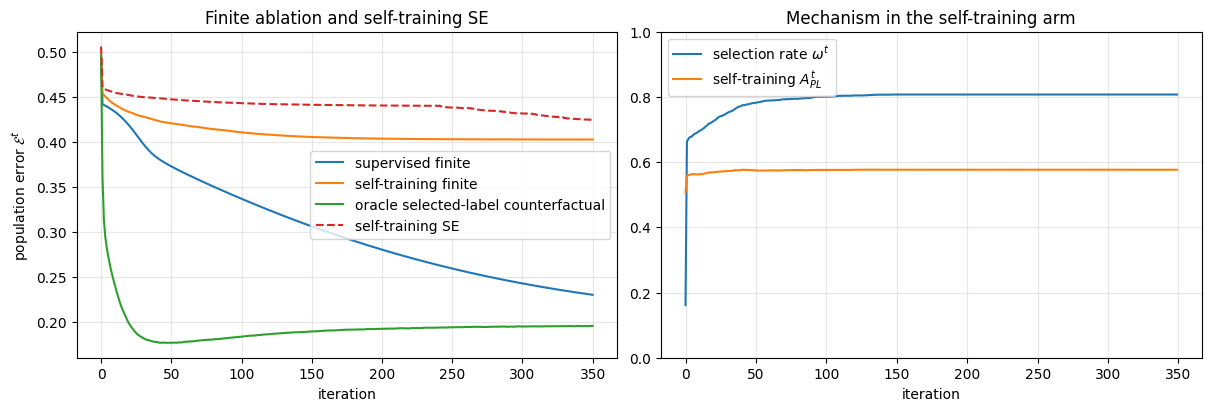

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(supervised.callback.history_["population_error"], label="supervised finite")
axes[0].plot(self_training.callback.history_["population_error"], label="self-training finite")
axes[0].plot(oracle_callback.history_["population_error"], label="oracle selected-label counterfactual")
axes[0].plot(state_evolution_state_observables(self_training)["error"], linestyle="--", label="self-training SE")
axes[0].set(title="Finite ablation and self-training SE", xlabel="iteration", ylabel=r"population error $\mathcal{E}^t$")

self_update = finite_update_observables(self_training)
axes[1].plot(self_update["omega"], label=r"selection rate $\omega^t$")
axes[1].plot(self_update["accuracy"], label=r"self-training $A_{PL}^t$")
axes[1].set(title="Mechanism in the self-training arm", xlabel="iteration", ylim=(0, 1))
for ax in axes: ax.grid(alpha=0.3); ax.legend()
plt.show()

## Fully supervised oracle and pseudo-label cost

The selected-label oracle is a dynamic counterfactual, not necessarily a pathwise upper bound.  The optional fully supervised oracle instead uses the same total sample size $n$ with every observation labelled.  It is a distinct benchmark and is labelled as such.

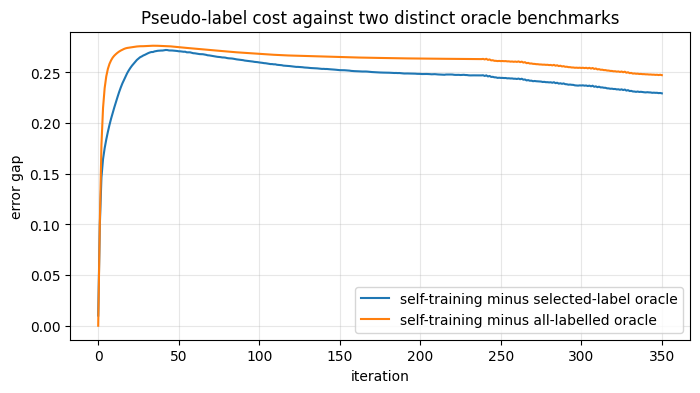

self-training {'terminal_error': 0.4246401024098916, 'minimum_error': 0.4246401024098916, 'best_iteration': 350, 'late_error_range': 0.0008141838557419456, 'terminal_normalized_bias': -0.2048712114998076, 'terminal_normalized_alignment': 0.06858865972958589, 'terminal_weight_scale': 1.759947255147572, 'collapsed': False}
all-labelled oracle {'terminal_error': 0.17726211512975348, 'minimum_error': 0.17248525219971572, 'best_iteration': 47, 'late_error_range': 4.305510504953869e-06, 'terminal_normalized_bias': -1.3032818695798947, 'terminal_normalized_alignment': 0.5769927003616911, 'terminal_weight_scale': 1.3154719726920445, 'collapsed': False}
{'positive': {'coverage': array([0.1622807 , 0.66666667, 0.66885965, 0.67324561, 0.67324561,
       0.67324561, 0.67324561, 0.6754386 , 0.68201754, 0.68859649,
       0.68859649, 0.68859649, 0.68859649, 0.69078947, 0.69517544,
       0.70175439, 0.70394737, 0.70614035, 0.71052632, 0.71052632,
       0.7127193 , 0.71710526, 0.71710526, 0.71929825

In [7]:
RUN_FULLY_SUPERVISED_ORACLE = True
if RUN_FULLY_SUPERVISED_ORACLE:
    fully_supervised = run_experiment(
        name="fully supervised oracle", d=D, delta=DELTA, n_test=4_000,
        label_prior=0.2, rho=1.0, sigma=1.0, signal_std=1.0,
        algo_cfg=make_algorithm_config(T=T, eta=0.5, penalty=0.1, pi=0.0, kappa=logit(0.8)),
        seed=SEED, K_w=K_W, K_g=K_G,
    )
    st_error = state_evolution_state_observables(self_training)["error"]
    selected_oracle_error = np.asarray(oracle_callback.history_["population_error"])
    all_label_error = state_evolution_state_observables(fully_supervised)["error"]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(st_error - selected_oracle_error, label="self-training minus selected-label oracle")
    ax.plot(st_error - all_label_error, label="self-training minus all-labelled oracle")
    ax.set(xlabel="iteration", ylabel="error gap", title="Pseudo-label cost against two distinct oracle benchmarks")
    ax.grid(alpha=0.3); ax.legend(); plt.show()
    print("self-training", trajectory_diagnostics(self_training))
    print("all-labelled oracle", trajectory_diagnostics(fully_supervised))
    print(class_conditional_update_observables(self_training, source="finite"))